## Importing the Libraries

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
np.random.seed(42)
import matplotlib.pyplot as plt

## Reading Csv File

In [23]:
df = pd.read_csv("./Datasets/tvmarketing.csv")
df.head()

,TV,Sales
0,230.1,22.1
1,44.5,10.4
2,17.2,9.3
3,151.5,18.5
4,180.8,12.9


## Linear Regression

In [24]:
X = df["TV"].to_numpy()
Y = df["Sales"]
# Normalizing the Data

X_norm = (X - np.mean(X))/(np.std(X))
Y_norm = (Y - np.mean(Y))/(np.std(Y))
print(X_norm.shape)
print(Y_norm.shape)



(200,)
(200,)


## Loss Function

A **loss function** measures how far the model's predicted values are from the actual values.

For Linear Regression, we use the **Mean Squared Error (MSE)** based cost function:

$$
J(W,b) = \frac{1}{2n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Where:

- $n$ = number of training samples
- $y_i$ = actual value
- $\hat{y}_i$ = predicted value
- $W$ = weights
- $b$ = bias

For Multiple Linear Regression:

$$
\hat{Y} = XW + b
$$

Therefore, the loss can be written as:

$$
J(W,b) = \frac{1}{2n}\sum_{i=1}^{n}(Y_i-\hat{Y}_i)^2
$$

### Why Square the Error?

Squaring the residuals:

- Prevents positive and negative errors from cancelling each other.
- Penalizes larger errors more strongly.
- Makes the loss differentiable, which is useful for Gradient Descent.

### Why use $\frac{1}{2n}$?

The factor $\frac{1}{n}$ takes the average error over all training samples.

The extra $\frac{1}{2}$ is used for mathematical convenience because when differentiating the squared error, the `2` produced by the derivative cancels with this $\frac{1}{2}$.




In [25]:
def loss_func(Y, Y_hat):
    return (1/(2*len(Y)))*np.sum((Y - Y_hat)**2)


## Gradient Descent

**Gradient Descent** is an optimization algorithm used to minimize the loss function by continuously updating the model parameters.

In Linear Regression, our goal is to find the optimal values of:

- $W$ = weights
- $b$ = bias

that minimize the cost function:

$$
J(W,b) = \frac{1}{2n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

### Basic Idea

Gradient Descent calculates the derivative (gradient) of the loss function with respect to each parameter.

The gradient tells us the direction in which the loss increases.

Therefore, to minimize the loss, we move in the **opposite direction of the gradient**.

### Weight Update

$$
W := W - \alpha \frac{\partial J}{\partial W}
$$

### Bias Update

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

Where:

- $\alpha$ = learning rate
- $\frac{\partial J}{\partial W}$ = gradient of loss with respect to weights
- $\frac{\partial J}{\partial b}$ = gradient of loss with respect to bias




In [26]:
def dEdm(x,Y, Y_hat):
    return 1/len(Y)*np.dot(Y_hat - Y,x)

def dEdb(Y, Y_hat):
    return 1/len(Y)*np.sum(Y_hat - Y)

### Training Function

In [27]:
def train(x,Y,m,b,learning_rate = 0.01,num_iter = 1000):
    for i in range(num_iter):
        Y_hat = m*x +b
        m = m - learning_rate * dEdm(x, Y, Y_hat)
        b = b - learning_rate * dEdb(Y, Y_hat)

        Y_hat = m*x +b
        loss = loss_func(Y,Y_hat)

        print(f"Loss in iteration {i} : {loss}")
    return m,b



In [28]:
m = 0 ; b =0
m,b = train(X_norm,Y_norm,m,b)
print(f"m = {m}, b = {b}")

Loss in iteration 0 : 0.4939118432440418
Loss in iteration 1 : 0.4879448408075272
Loss in iteration 2 : 0.48209658171949926
Loss in iteration 3 : 0.4763647029873229
Loss in iteration 4 : 0.470746888641917
Loss in iteration 5 : 0.4652408688019847
Loss in iteration 6 : 0.45984441875686694
Loss in iteration 7 : 0.4545553580676471
Loss in iteration 8 : 0.4493715496861427
Loss in iteration 9 : 0.44429089909143027
Loss in iteration 10 : 0.43931135344355254
Loss in iteration 11 : 0.4344309007540677
Loss in iteration 12 : 0.42964756907310353
Loss in iteration 13 : 0.4249594256925906
Loss in iteration 14 : 0.4203645763653498
Loss in iteration 15 : 0.4158611645397211
Loss in iteration 16 : 0.4114473706094225
Loss in iteration 17 : 0.40712141117833667
Loss in iteration 18 : 0.4028815383399297
Loss in iteration 19 : 0.39872603897100684
Loss in iteration 20 : 0.3946532340395257
Loss in iteration 21 : 0.39066147792618083
Loss in iteration 22 : 0.3867491577594917
Loss in iteration 23 : 0.382914692764

### Predict Function

In [29]:
def predict(m,b,X):
    return m*X + b

In [30]:
Y_hat = predict(m,b,X_norm)
loss = loss_func(Y_norm,Y_hat)
loss

np.float64(0.19406247514515756)

### Denormalization

After prediction, the output is still in the normalized scale.

To bring predictions back to their original units, we reverse the normalization:

$$
Y_{\text{original}} = Y_{\text{normalized}} \times \sigma_Y + \mu_Y
$$

In NumPy:

```python
Y_hat_original = Y_hat * np.std(Y) + np.mean(Y)
```

In [31]:

Y_pred_original = Y_hat * np.std(Y) + np.mean(Y)

In [32]:
df = pd.DataFrame({
    "Actual" : Y,
    "Predicted" : Y_pred_original,
    "Residual": Y - Y_pred_original
}
 )

In [33]:
df.head(10)

,Actual,Predicted,Residual
0,22.1,17.970604,4.129396
1,10.4,9.148184,1.251816
2,9.3,7.850490,1.449510
3,18.5,14.234385,4.265615
4,12.9,15.627149,-2.727149
5,7.2,7.446446,-0.246446
6,11.8,9.766134,2.033866
7,13.2,12.746553,0.453447
8,4.8,7.441693,-2.641693
9,10.6,16.530306,-5.930306


### plotting out line

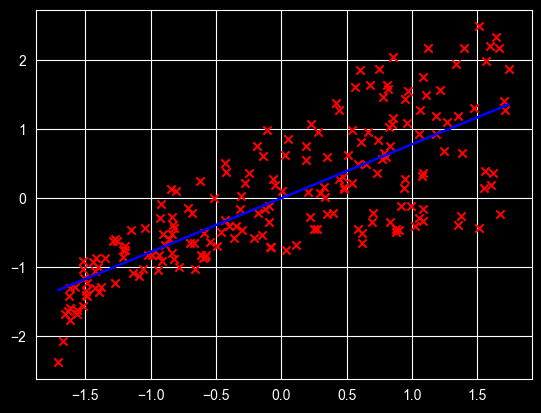

In [34]:
plt.scatter(X_norm,Y_norm, marker="x", c="r")
plt.plot(X_norm,Y_hat, c="b")

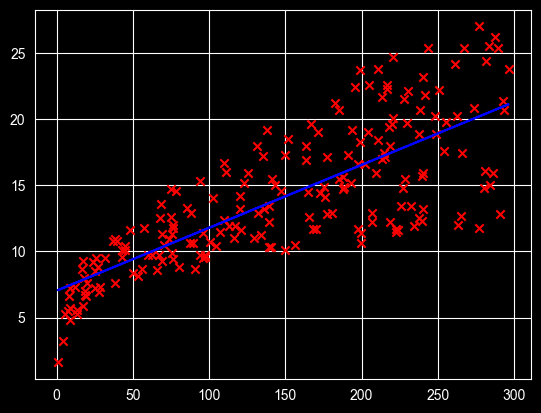

In [35]:
plt.scatter(X,Y, marker="x", c="r")
plt.plot(X,Y_pred_original, c="b")

### Comparison with Sklearn

In [36]:
## it require 2d array
X_sklearn = X_norm.reshape(-1, 1)

model = LinearRegression()
model.fit(X_sklearn, Y_norm)
print("m:",m)
print("b:", b)
print("Sklearn m:", model.coef_[0])
print("Sklearn b:", model.intercept_)

m: 0.7821906552574298
b: -2.77422529393339e-16
Sklearn m: 0.7822244248616067
Sklearn b: -2.642826921026317e-16


## Multiple Regression

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


(414, 8)

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


W vector is [[ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337 -0.23413696]]
shape of X = (6, 414) 
shape of Y = (414,) 


[[5191280.17625651   46250.35917643    7136.88903806 5225247.91118616
    64372.74940278  313370.65260171]]
2578.6703686550504


array([[ 1096.86269094,  1435.62400014,  1823.18522043,  1823.1438276 ,
         1562.89067649,  4279.02127756,  1914.74670403,  1404.89232523,
         9357.11072191,  3681.09976879,  1578.61201779,  1108.47101797,
         1716.66610603,  4726.53844032,  2740.67519126,  1844.3780471 ,
         1415.83366708,  1498.01610498,  1529.31568591,  1005.35568494,
         4433.34651237,  1394.05648523,  3035.6901248 ,  1393.94621953,
         1694.81365403,  3228.93884194,  1552.8564664 ,  1388.55002601,
         1814.82134363,  1655.1347702 ,  7845.88732084,  2137.72152882,
         1704.97634483,  1460.24432432,  1280.63832642,  7176.97834121,
         3911.8871424 ,  3036.18761696,  1849.12417426,  1407.30979815,
         7180.74723439,  7157.05559989,  1755.1937125 ,  1745.57270075,
         1780.5863121 ,  1710.22939874,  1675.24489281,  1938.71503008,
         7977.15175731,  7831.42563784,  1746.00556385,  3640.04876106,
         3154.37936073,  1716.70741239,  1407.28223171,  2728.80

In [46]:
print("W:", W)
print("b:", b)

Y_hat = W @ X_norm + b
print("Final Loss:", loss_func(Y_norm, Y_hat))


W: [[ 0.10668663 -0.2258211   0.2454574  -0.41569655  0.20578124 -0.01361895]]
b: 4.17883655751908e-15
Final Loss: 0.20880751516020357


Loss in 0 iteration : 1.7199789724177592
Loss in 1 iteration : 1.1665134556952574
Loss in 2 iteration : 0.8556565753282327
Loss in 3 iteration : 0.676862710354655
Loss in 4 iteration : 0.5705097827680485
Loss in 5 iteration : 0.5043555126590954
Loss in 6 iteration : 0.4608932708329877
Loss in 7 iteration : 0.43055894364854647
Loss in 8 iteration : 0.40807916618457013
Loss in 9 iteration : 0.3905065282164612
Loss in 10 iteration : 0.37616103433894993
Loss in 11 iteration : 0.36405866841912704
Loss in 12 iteration : 0.35360198171879237
Loss in 13 iteration : 0.3444117984735935
Loss in 14 iteration : 0.3362350601237509
Loss in 15 iteration : 0.32889386084414973
Loss in 16 iteration : 0.3222568579841946
Loss in 17 iteration : 0.31622290950125015
Loss in 18 iteration : 0.31071145193599753
Loss in 19 iteration : 0.3056566417492597
Loss in 20 iteration : 0.3010036356566716
Loss in 21 iteration : 0.29670611660879626
Loss in 22 iteration : 0.29272456842011946
Loss in 23 iteration : 0.2890250180

Scratch W: [[ 0.10668663 -0.2258211   0.2454574  -0.41569655  0.20578124 -0.01361895]]
Scratch b: 4.17883655751908e-15
Sklearn W: [ 0.10671371 -0.22581256  0.24534464 -0.41625196  0.20564666 -0.01401913]
Sklearn b: 3.4405522650543835e-15


### For Second Approach which used in Sklearn


W1 is [[1.57921282]
 [0.76743473]]
shape of X1 = (414, 2) 
shape of Y1 = (414,) 


 Loss After iter 0 is : 1.6715424249787232
 Loss After iter 1 is : 1.409682167168485
 Loss After iter 2 is : 1.198226889078374
 Loss After iter 3 is : 1.0274550195612777
 Loss After iter 4 is : 0.8895235741206814
 Loss After iter 5 is : 0.7781044675920027
 Loss After iter 6 is : 0.6880913603888902
 Loss After iter 7 is : 0.6153633357622429
 Loss After iter 8 is : 0.5565943718334849
 Loss After iter 9 is : 0.5090997188515064
 Loss After iter 10 is : 0.47071202060042355
 Loss After iter 11 is : 0.4396814107478581
 Loss After iter 12 is : 0.41459493582385504
 Loss After iter 13 is : 0.3943115592888181
 Loss After iter 14 is : 0.3779097282997079
 Loss After iter 15 is : 0.3646450705336415
 Loss After iter 16 is : 0.35391626031695445
 Loss After iter 17 is : 0.34523747350388917
 Loss After iter 18 is : 0.3382161568979321
 Loss After iter 19 is : 0.33253508487753525
 Loss After iter 20 is : 0.32793787484413317
 Loss After iter 21 is : 0.3242172934684212
 Loss After iter 22 is : 0.32120581497

W from scratch [[-0.23947327]
 [ 0.58288081]]
b1 from scratch 7.63747626602039e-17
SkLearn W1 [[-0.23947358  0.58288101]]
SkLearn b1 [6.80995133e-17]


,Y_orignal,Y_predicted
0,37.9,49.795240
1,42.2,50.677881
2,47.3,41.681109
3,54.8,41.681109
4,43.1,44.055011


(414,)

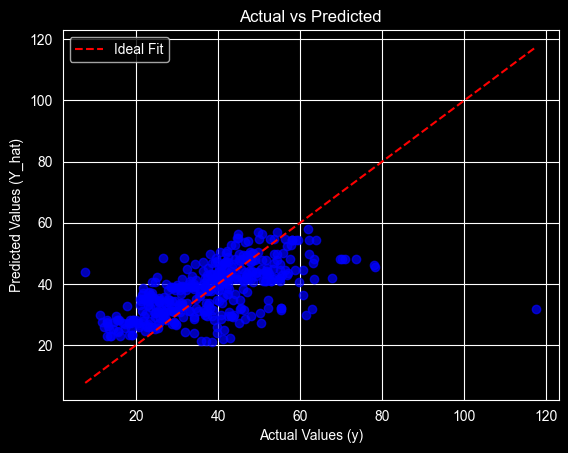